In [1]:
import pandas as pd
import numpy as np, random
random.seed(42)

In [2]:
dfraw = pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/presplit/dfraw.csv')

#En este documento , vamos a preparar las variables para un modelo de regression, a priori vamos a escoger un modelo que nos permita tambien tener como variables predictoras mas de un tipo de variable, no solo escalas float
#Ademas prepararemos las variables target a variables escalables tipo float 0 a 10.



In [3]:
dfraw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62664 entries, 0 to 62663
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   pplfair                         62664 non-null  int64  
 1   pplhlp                          62664 non-null  int64  
 2   ppltrst                         62664 non-null  int64  
 3   lrscale                         62664 non-null  int64  
 4   polintr                         62664 non-null  int64  
 5   stfdem                          62664 non-null  int64  
 6   stfeco                          62664 non-null  int64  
 7   stfgov                          62664 non-null  int64  
 8   trstep                          62664 non-null  int64  
 9   trstlgl                         62664 non-null  int64  
 10  trstplc                         62664 non-null  int64  
 11  trstplt                         62664 non-null  int64  
 12  trstprl                         

In [4]:
#Nos interesa pasar a escala float las variables que a priori son objetivo de ser las tarjet.


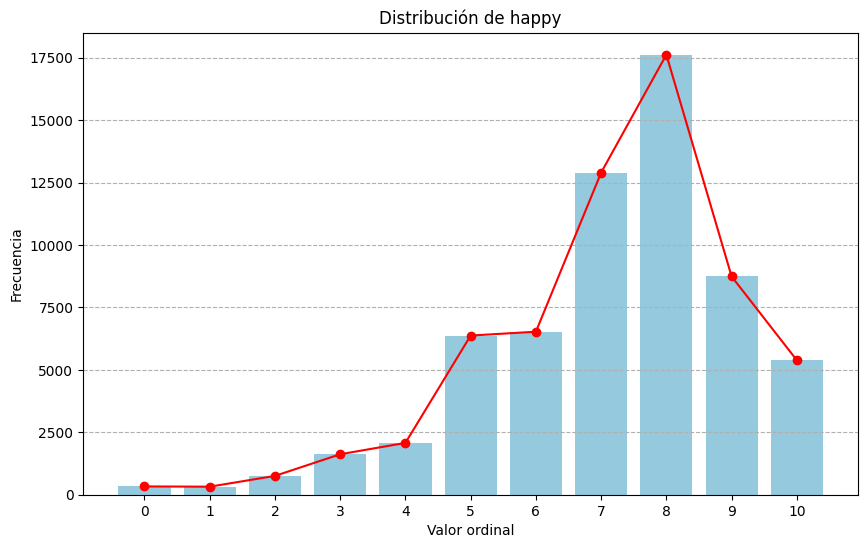

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visdist(df, columna):

    
    frecuencias = df[columna].value_counts().sort_index()

   
    plt.figure(figsize=(10, 6))
    sns.barplot(x=frecuencias.index, y=frecuencias.values, color='skyblue')
    plt.plot(frecuencias.index, frecuencias.values, marker='o', color='red')

    # Añadir etiquetas y título
    plt.xlabel('Valor ordinal')
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {columna}')
    plt.xticks(frecuencias.index)  
    plt.grid(axis='y', linestyle='--')

    # Mostrar el gráfico
    plt.show()


visdist(dfraw, 'happy')

In [6]:
dfraw['happy'].describe()

count    62664.000000
mean         7.179593
std          1.883989
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: happy, dtype: float64

Voy a crear dos variables antes de hacer un submuestreo, voy a crear una variable  ternaria de infelicidad siendo clase 2 infeliz, 1 algo infeliz y clase 0 no feliz(que no quiere decir que seas feliz) si no que el valor en happyscl es 0 (antiguo valor 5 medio de happy). Derivo happy en una binaria de infelicidad y una escala float 'happyscl' donde el 0 empieza en el 5 de la antigua happy y el 10 de happyscl coincide con el max de happy 

In [7]:
import pandas as pd

import pandas as pd

def crear_variables_felicidad(df):
    """
    Crea una variable ternaria de infelicidad y una escala de felicidad a partir de la variable 'happy'.

    Args:
        df (pd.DataFrame): DataFrame con la variable 'happy'.

    Returns:
        pd.DataFrame: DataFrame con las nuevas variables 'infelicidad_ternaria' y 'happyscl'.
    """
    # Variable ternaria de infelicidad
    df['infelicidad_ternaria'] = pd.cut(df['happy'], bins=[-float('inf'), 2, 4, float('inf')], labels=[2, 1, 0], right=False)
    df['infelicidad_ternaria'] = df['infelicidad_ternaria'].astype(int)

    # Nueva escala 'happyscl' (con mapeo de valores <= 4 a 0)
    min_happy = 5  # Valor mínimo de la nueva escala (50% de la escala original)
    max_happy = df['happy'].max()  # Valor máximo de 'happy'

    df['happyscl'] = (df['happy'] - min_happy) * (10 / (max_happy - min_happy))
    df.loc[df['happy'] <= 4, 'happyscl'] = 0  # Mapeo de valores <= 4 a 0

    return df

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame original llamado df
df = crear_variables_felicidad(dfraw)

# Verificar la nueva escala
print(df['happyscl'].describe())

count    62664.000000
mean         4.695200
std          3.052363
min          0.000000
25%          2.000000
50%          6.000000
75%          6.000000
max         10.000000
Name: happyscl, dtype: float64


In [8]:
dfraw['happyscl'].describe()


count    62664.000000
mean         4.695200
std          3.052363
min          0.000000
25%          2.000000
50%          6.000000
75%          6.000000
max         10.000000
Name: happyscl, dtype: float64

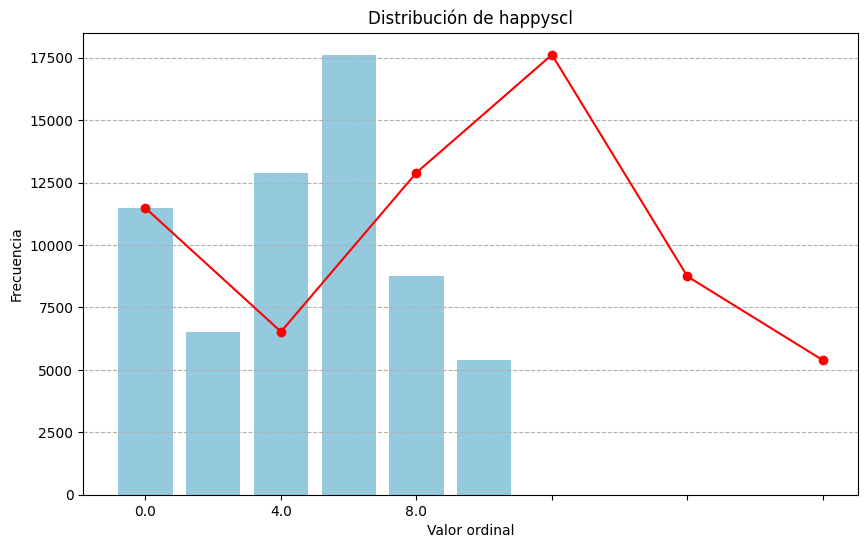

In [9]:
visdist(dfraw, 'happyscl')

In [10]:
import pandas as pd

print(df['happy'].value_counts())

happy
8     17624
7     12901
9      8743
6      6529
5      6375
10     5387
4      2076
3      1621
2       754
0       332
1       322
Name: count, dtype: int64


In [11]:
import pandas as pd
from sklearn.utils import resample

def submuestrear_y_convertir_happy(df):
    """
    Realiza un submuestreo de todas las clases mayoritarias de la variable 'happy' y la convierte a float.

    Args:
        df (pd.DataFrame): DataFrame con la variable 'happy'.

    Returns:
        pd.DataFrame: DataFrame con la variable 'happy' submuestreada y convertida a float.
    """
    # Determinamos el tamaño mínimo de la clase
    min_class_size = df['happy'].value_counts().min()

    # Lista para almacenar los DataFrames submuestreados
    df_submuestreados = []

    # Submuestreo de cada clase
    for clase in df['happy'].unique():
        df_clase = df[df['happy'] == clase]
        df_clase_submuestreada = resample(df_clase,
                                          replace=False,
                                          n_samples=min_class_size,
                                          random_state=42)
        df_submuestreados.append(df_clase_submuestreada)

    # Combinar los DataFrames submuestreados
    df_submuestreado = pd.concat(df_submuestreados)

    # Convertir la variable 'happy' a float
    df_submuestreado['happy'] = df_submuestreado['happy'].astype(float)

    # Comprobaciones adicionales
    print(f"Tamaño del DataFrame submuestreado: {len(df_submuestreado)}")
    print(df_submuestreado['happy'].value_counts())

    return df_submuestreado

# Ejemplo de uso:
# Supongamos que tienes tu DataFrame original llamado df
df_submuestreado = submuestrear_y_convertir_happy(df)

# Verificar el resultado
print(df_submuestreado['happy'].describe())

Tamaño del DataFrame submuestreado: 3542
happy
7.0     322
10.0    322
8.0     322
9.0     322
2.0     322
5.0     322
6.0     322
3.0     322
0.0     322
1.0     322
4.0     322
Name: count, dtype: int64
count    3542.000000
mean        5.000000
std         3.162724
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: happy, dtype: float64


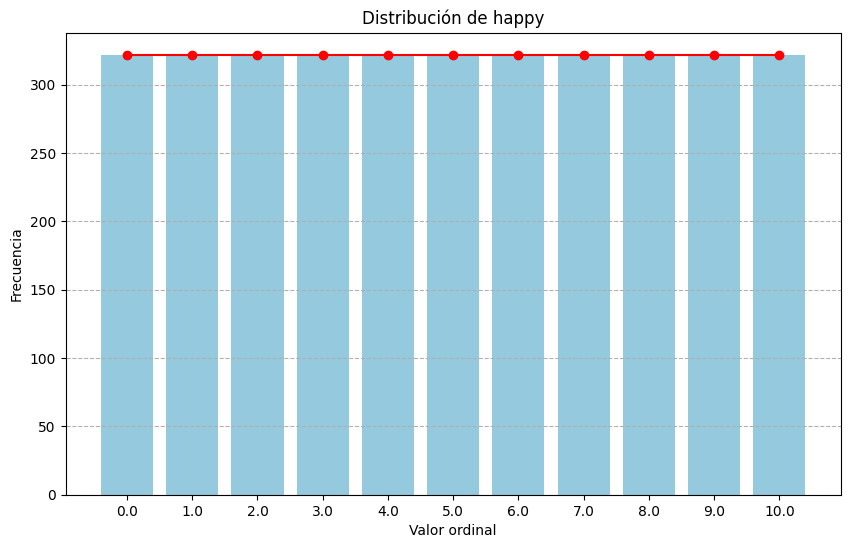

In [12]:

visdist(df_submuestreado, 'happy')

In [13]:
print(df_submuestreado.columns)

Index(['pplfair', 'pplhlp', 'ppltrst', 'lrscale', 'polintr', 'stfdem',
       'stfeco', 'stfgov', 'trstep', 'trstlgl', 'trstplc', 'trstplt',
       'trstprl', 'trstprt', 'trtsci_pnd', 'imbgeco', 'imwbcnt', 'happy',
       'rlgdgr', 'cntgrp_fc', 'lw_pnd', 'cnt_fc', 'rel3fc', 'happyfc',
       'confianza_promedio', 'confianza_promedio_factorizada', 'satisf_media',
       'satisf_media_factorizada', 'pintfc', 'ppl', 'ppl_fc', 'lrscale_fc',
       'lrscale2_fc', 'lrfc3d', 'relbin', 'sm3d', 'sm4d', 'lr4d', 'confM4d',
       'pplfair3d', 'pplhlp3d', 'ppltrst3d', 'stfdem3d', 'stfeco3d',
       'stfgov3d', 'trstep3d', 'trstlgl3d', 'trstplc2fc', 'trstplt2fc',
       'trstprl3d', 'ContNeutro', 'ConfNeutro', 'ConfPplmean', 'ConfLegalMean',
       'ConfPoliticaMean', 'ConfSciMean', 'ConfPplBin', 'ConfLegalBin',
       'ConfPoliticaBin', 'ConfSciBin', 'ContNeutroSat', 'SatNeutro',
       'SatInmigracionMean', 'SatGobiernoMean', 'SatDineroMean',
       'SatInmigracionBin', 'SatGobiernoBin', 'SatDine

In [14]:
df_submuestreado = df_submuestreado.drop(['infelicidad_ternaria', 'happyscl','happyfc','lrscale_fc',
       'lrscale2_fc', 'lrfc3d','lr4d','lrscale','polintr',], axis=1)

In [15]:
import pandas as pd

# Supongamos que tienes tu DataFrame llamado df_submuestreado
# Seleccionar solo las columnas de tipo float
float_cols = df_submuestreado.select_dtypes(include=['float']).columns

# Redondear todas las columnas float a 6 decimales
df_submuestreado[float_cols] = df_submuestreado[float_cols].round(2)

# Ahora puedes usar df_submuestreado en tu lazypredict.

In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
X = df_submuestreado.drop('happy', axis=1) 
y = df_submuestreado['happy'] 
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
dfhappy = pd.DataFrame(X_scaled, columns=X.columns)


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
from imblearn.over_sampling import SMOTE

# Supongamos que df es tu DataFrame

# Separamos las target
X = df_submuestreado.drop(['happy'], axis=1)
y = df_submuestreado['happy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Guardamos los split.
joblib.dump((X_train, X_test, y_train, y_test), "C:/Users/Josue/4GA.Datascience/4GA.DataScience/models/Split/happyfloat/splitHappySCL.pkl")

print("Splits guardados correctamente.")

Splits guardados correctamente.


Tras todas las pruebas realizadas y feature engineering, deduzco que no hay suficientes variables predictoras relevantes para realizar un modelo de regresion/clasificacion para las variables target happy, lrscale y polintr.
Por lo que bajare un nuevo csv de la web con mas variables para cada una de esas variables y realizare un modelo para cada uno de ellas.
La unica variable que si ha tenido una alta correlacion e influencia ha sido la de mi hipotesis, agrupar los paises por razones economicas (grupo0 ricos, grupo1 media ue y grupo 2 pobres,.)